In [8]:
import sys
sys.path.append('/Users/akeow/Desktop/TEAMER HDPS/HDPSTeamer/TurboShipCostCalculator/')

import matplotlib.pyplot as plt
import autograd.numpy as np  # Thinly-wrapped numpy
plt.style.use('tableau-colorblind10')


import funcTidal # module for acquiring tidal data from NOAA

import constUnitConvert
CONVERT = constUnitConvert.ConstantsUnitConversion()


This tutorial guides user on how to obtain tidal data from NOAA current prediction buoys.
Most of the functions requires are in `funcTidal`

- Find list of availble station ID at this site [NOAA Buoy List](https://tidesandcurrents.noaa.gov/noaacurrents/Stations?g=693)
- Code works only with **Harmonic** predictions
- More information about the API can be found here [API Info](https://api.tidesandcurrents.noaa.gov/mdapi/prod/#request)


In [9]:
mystation = "SEA0712"
mystartdate = 20210101  # must be in this format
myrangeHr = 2 * 7 * 24    # desired time range of data in hours
mytimestep = 0.2          # time step in seconds to interpolate data between points
Uinf, t, dMoor, buoyLatitude, buoyLongitude = funcTidal.loadTidal(mystation, mystartdate, myrangeHr, mytimestep)


print(f"Mooring depth is {dMoor} [m].")


/Users/akeow/opt/anaconda3/envs/TeamerHDPS/lib/python3.11/site-packages/urllib3/connectionpool.py:1103: InsecureRequestWarning: Unverified HTTPS request is being made to host 'proxy.sandia.gov'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/Users/akeow/opt/anaconda3/envs/TeamerHDPS/lib/python3.11/site-packages/urllib3/connectionpool.py:1103: InsecureRequestWarning: Unverified HTTPS request is being made to host 'proxy.sandia.gov'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


Mooring depth is 40.8 [m].


Plot the tidal data

Text(0, 0.5, 'Flow Speed [m/s]')

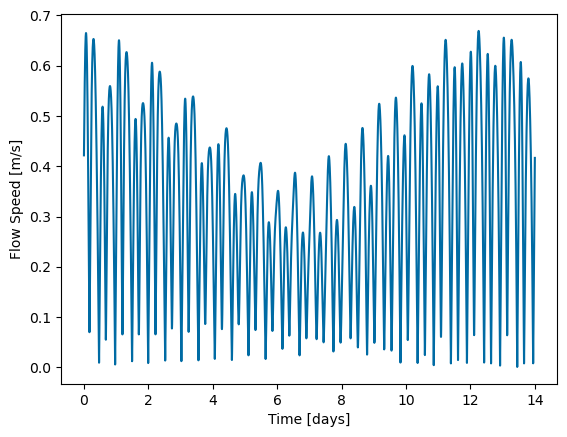

In [10]:
plt.plot(t*CONVERT.sec2days,Uinf)
plt.xlabel("Time [days]")
plt.ylabel('Flow Speed [m/s]')

Use the buoy longitude and latitude and text file containing list of major city at Alaska (`AlaskaCityLatLong.txt`) to calculate the distance of the prediction buoy to the nearest city
- this is use for estimating cable length
- `buoyLatitude` and `buoyLatitude` which are output from `funcTidal.loadTidal` must be given

In [11]:
dCable, CityName = funcTidal.calCableLen(buoyLatitude, buoyLongitude, "/Users/akeow/Desktop/TEAMER HDPS/HDPSTeamer/TurboShipCostCalculator/AlaskaCityLatLong.txt")
cable_length_miles = dCable * CONVERT.m2mile
print(f"Cable length is {round(cable_length_miles, 2)} miles and the closest city is {CityName}.")


Cable length is 2.89 miles and the closest city is Ketchikan.


This file also contains function to adjust the flow speed of the tidal buoy as the water dpeth changing. 

Code below shows how to use the code to calculate the speed at various depth.

- Radius, hub depth, mooring depth (from `funcTidal.loadTidal`) must be given

/Users/akeow/opt/anaconda3/envs/TeamerHDPS/lib/python3.11/site-packages/matplotlib/cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/akeow/opt/anaconda3/envs/TeamerHDPS/lib/python3.11/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


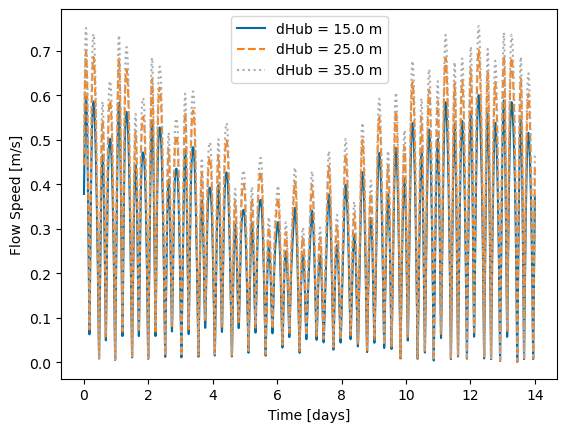

In [14]:
Radius = 1.0 # meters
dHub_values = [15.0, 25.0, 35.0] # meters (example values)
line_styles = ['-', '--', ':'] # example line styles

for dHub, line_style in zip(dHub_values, line_styles):
    U_depth = funcTidal.flowAtDepth(Uinf, Radius, dHub, dMoor)
    plt.plot(t * CONVERT.sec2days, U_depth, label=f'dHub = {dHub} m', linestyle=line_style)

plt.xlabel("Time [days]")
plt.ylabel('Flow Speed [m/s]')
plt.legend()
plt.show()

This is an illustrative example on how flow speed changes with depth.

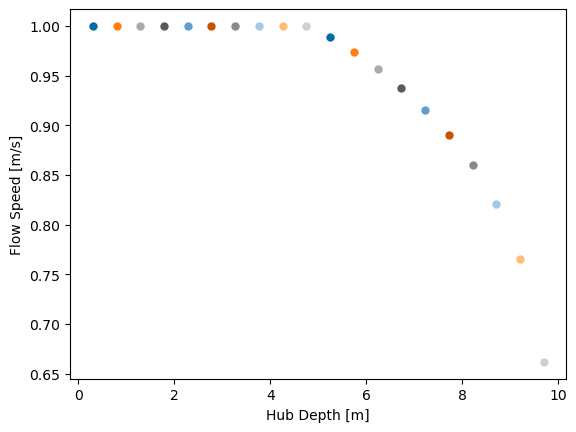

In [13]:

Radius = 0.2
dHubVector = np.linspace(Radius + 0.1, 10 - Radius - 0.1, 20)
dMoor = 10
UinfIN = 1

for x in dHubVector:
    Unew = funcTidal.flowAtDepth(UinfIN, Radius, x, dMoor)
    plt.plot(x, Unew, '.', markersize=10)

plt.xlabel('Hub Depth [m]')
plt.ylabel('Flow Speed [m/s]')
plt.show()
